In [105]:
import pandas as pd
import numpy as np

n_rows = 2000

# 1. Lists-ka xogta
occupations = ['Business', 'Farmer', 'Teacher', 'Unemployed']
regions = ['Banadir', 'Bari', 'Nugaal', 'Hiran', 'Gedo', 'Lower Shabelle', 'Galgaduud']
schools = ['Public', 'Private']

def assign_education(job):
    if job == 'Teacher':
        return np.random.choice(['Secondary', 'University'])
    return np.random.choice(['None', 'Primary', 'Secondary', 'University'])

# 2. Diyaarinta Xogta
parent_jobs = np.random.choice(occupations, size=n_rows)
data = {
    'gpa': np.round(np.random.uniform(0, 100, size=n_rows), 1),
'family_income': np.random.randint(50, 2001, size=n_rows),
    'parents_education': [assign_education(j) for j in parent_jobs],
    'is_orphan': np.random.choice([0, 1], size=n_rows, p=[0.7, 0.3]),
    'is_displaced': np.random.choice([0, 1], size=n_rows, p=[0.7, 0.3]),
    'region': np.random.choice(regions, size=n_rows),
    'parent_occupation': parent_jobs,
    'gap_years': np.random.randint(0, 6, size=n_rows), 
    'high_school_type': np.random.choice(schools, size=n_rows),
    'has_verification': np.random.choice([0, 1], size=n_rows, p=[0.2, 0.8]),
    'gender': np.random.choice(['Male', 'Female'], size=n_rows),
    'faculty': np.random.choice(['CS', 'Medicine', 'Eng', 'Agri'], size=n_rows)
}

df = pd.DataFrame(data)


def calculate_eligibility_fixed(row):
    # --- HARD CONSTRAINTS ---
    if row['has_verification'] == 0 or row['gpa'] < 50 or row['family_income'] > 500:
        return 0

    # --- POINT SYSTEM ---
    score = 25 # Verification points
    
    if row['gpa'] >= 90: score += 20
    elif row['gpa'] >= 80: score += 15
    elif row['gpa'] >= 70: score += 10
    
    if row['is_orphan'] == 1: score += 10
    if row['is_displaced'] == 1: score += 10
    
    if row['family_income'] < 150: score += 15
    elif row['family_income'] < 300: score += 10
    
    if row['gap_years'] <= 3: score += 10
    if row['parent_occupation'] == 'Unemployed': score += 20
    elif row['parent_occupation'] == 'Farmer': score += 15

    return 1 if score >= 45 else 0

# Codso function-ka
df['scholarship_eligible'] = df.apply(calculate_eligibility_fixed, axis=1)

# 4. Hubinta Tayada (Sanity Check)
print(f"Tirada Eligible (1): {df['scholarship_eligible'].sum()}")
print(f"Tirada Rejected (0): {len(df) - df['scholarship_eligible'].sum()}")

# Hubi haddii uu jiro qof aan warqad haysan oo la ogolaaday (Waa inuu 0 noqdaa)
errors = df[(df['has_verification'] == 0) & (df['scholarship_eligible'] == 1)]
print(f"Khaladaadka shuruudaha adag: {len(errors)}")

# 5. Kaydi Xogta (Dataset-ka rasmiga ah)
df.to_csv('scholarship_dataset.csv', index=False)
print("Dataset-kii waa la kaydiyey: scholarship_dataset.csv")

Tirada Eligible (1): 183
Tirada Rejected (0): 1817
Khaladaadka shuruudaha adag: 0
Dataset-kii waa la kaydiyey: scholarship_dataset.csv


In [106]:
def assign_education(job):
    if job == 'Teacher':
        # Halkan waxaan ku koobnay labada heer ee aad codsatay
        return np.random.choice(['Secondary', 'University'])
    else:
        # Shaqooyinka kale waxay yeelan karaan heer kasta (Primary ilaa University)
        return np.random.choice(['None', 'Primary', 'Secondary', 'University'])

In [107]:
print('DataFrame Info:')
display(df.info())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gpa                   2000 non-null   float64
 1   family_income         2000 non-null   int32  
 2   parents_education     2000 non-null   object 
 3   is_orphan             2000 non-null   int64  
 4   is_displaced          2000 non-null   int64  
 5   region                2000 non-null   object 
 6   parent_occupation     2000 non-null   object 
 7   gap_years             2000 non-null   int32  
 8   high_school_type      2000 non-null   object 
 9   has_verification      2000 non-null   int64  
 10  gender                2000 non-null   object 
 11  faculty               2000 non-null   object 
 12  scholarship_eligible  2000 non-null   int64  
dtypes: float64(1), int32(2), int64(4), object(6)
memory usage: 187.6+ KB


None

In [108]:
print('\nFirst 5 rows of the DataFrame:')
display(df.head(10))


First 5 rows of the DataFrame:


,gpa,family_income,parents_education,is_orphan,is_displaced,region,parent_occupation,gap_years,high_school_type,has_verification,gender,faculty,scholarship_eligible
0,23.7,159,Secondary,0,1,Galgaduud,Unemployed,5,Private,1,Male,Agri,0
1,62.3,1472,Primary,1,0,Nugaal,Unemployed,4,Private,1,Male,CS,0
2,66.8,79,Secondary,1,1,Lower Shabelle,Teacher,2,Public,1,Female,CS,1
3,4.0,231,Secondary,0,0,Hiran,Farmer,4,Public,1,Male,Medicine,0
4,16.2,447,University,0,0,Nugaal,Farmer,2,Private,1,Female,Eng,0
5,70.2,703,Primary,0,0,Galgaduud,Business,1,Private,1,Female,Agri,0
6,55.0,913,None,0,0,Galgaduud,Farmer,3,Private,1,Male,Eng,0
7,89.9,968,Primary,0,0,Hiran,Unemployed,2,Private,1,Female,Medicine,0
8,94.2,82,University,0,0,Hiran,Teacher,3,Private,0,Female,Medicine,0
9,68.8,1260,University,0,0,Hiran,Teacher,2,Public,0,Male,Agri,0


In [109]:
import pandas as pd

# Soo ridi dataset-kii
df = pd.read_csv('scholarship_dataset.csv')

# 1. Hubi qof aan warqad haysan laakiin la doortay (Waa inuu noqdaa 0)
error_check = df[(df['has_verification'] == 0) & (df['scholarship_eligible'] == 1)]
print(f"Khaladaadka la helay (Warqad la'aan): {len(error_check)}")

# 2. Fiiri inta Yatiim ah ee la doortay (1)
orphan_eligible = df[(df['is_orphan'] == 1) & (df['scholarship_eligible'] == 1)]
print(f"Yatiimiinta la doortay: {len(orphan_eligible)}")

# 3. Fiiri inta qof ee caadiga ah ee la doortay
normal_eligible = df[(df['is_orphan'] == 0) & (df['is_displaced'] == 0) & (df['scholarship_eligible'] == 1)]
print(f"Dadka caadiga ah ee la doortay: {len(normal_eligible)}")

Khaladaadka la helay (Warqad la'aan): 0
Yatiimiinta la doortay: 68
Dadka caadiga ah ee la doortay: 76


In [110]:
import pandas as pd

# Soo ridi dataset-ka
df = pd.read_csv('scholarship_dataset.csv')

# Halkan ka eeg tirada guud ee 0 iyo 1
print(df['scholarship_eligible'].value_counts())

scholarship_eligible
0    1817
1     183
Name: count, dtype: int64


In [111]:
print(df['scholarship_eligible'].value_counts(normalize=True) * 100)

scholarship_eligible
0    90.85
1     9.15
Name: proportion, dtype: float64


In [112]:
import pandas as pd

# Soo ridi dataset-ka
df = pd.read_csv('scholarship_dataset.csv')

print("--- WARBIXINTA DEEQDA WAXBARASHADA ---")

# 1. Sababta Koowaad: Warqad la'aan (has_verification = 0)
no_verify = df[df['has_verification'] == 0]
print(f"Total la diiday (Warqad la'aan darteed): {len(no_verify)}")

# 2. Kuwa haysta warqad laakiin la diiday (Dhibco hoose ama nasiib darro)
has_verify_but_rejected = df[(df['has_verification'] == 1) & (df['scholarship_eligible'] == 0)]
print(f"Total la diiday (Inkastoo ay warqad haysteen): {len(has_verify_but_rejected)}")

# 3. Kuwa la ogolaaday (Eligible = 1) - Maxay u soo baxeen?
eligible = df[df['scholarship_eligible'] == 1]
print(f"\n--- SABABAHA LOO OGOLAADAY {len(eligible)} QOF ---")
print(f"Yatiimiin la ogolaaday: {len(eligible[eligible['is_orphan'] == 1])}")
print(f"Barakac la ogolaaday: {len(eligible[eligible['is_displaced'] == 1])}")
print(f"Dad caadi ah (GPA sare): {len(eligible[(eligible['is_orphan'] == 0) & (eligible['is_displaced'] == 0)])}")

--- WARBIXINTA DEEQDA WAXBARASHADA ---
Total la diiday (Warqad la'aan darteed): 391
Total la diiday (Inkastoo ay warqad haysteen): 1426

--- SABABAHA LOO OGOLAADAY 183 QOF ---
Yatiimiin la ogolaaday: 68
Barakac la ogolaaday: 64
Dad caadi ah (GPA sare): 76


In [113]:
print(eligible.sort_values(by='gpa', ascending=False).head(5))

       gpa  family_income parents_education  is_orphan  is_displaced  \
1089  99.4            322        University          1             1   
1738  99.3            304        University          0             0   
1148  99.2            287               NaN          0             0   
652   99.1            257        University          0             1   
1186  98.8            177         Secondary          0             0   

         region parent_occupation  gap_years high_school_type  \
1089       Gedo            Farmer          4           Public   
1738      Hiran            Farmer          2          Private   
1148  Galgaduud            Farmer          3          Private   
652     Banadir           Teacher          3          Private   
1186       Bari           Teacher          2           Public   

      has_verification  gender   faculty  scholarship_eligible  
1089                 1  Female       Eng                     1  
1738                 1    Male        CS      

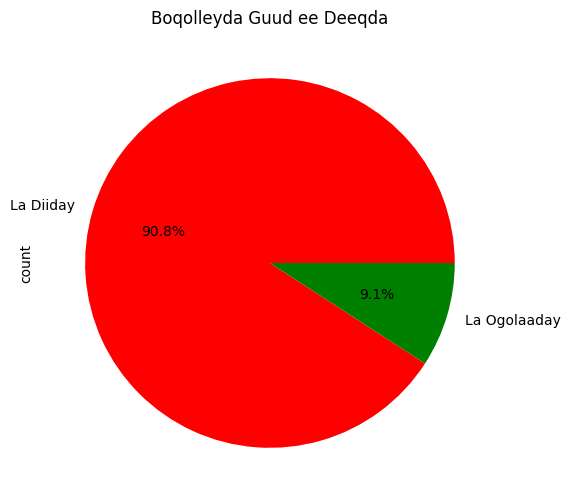

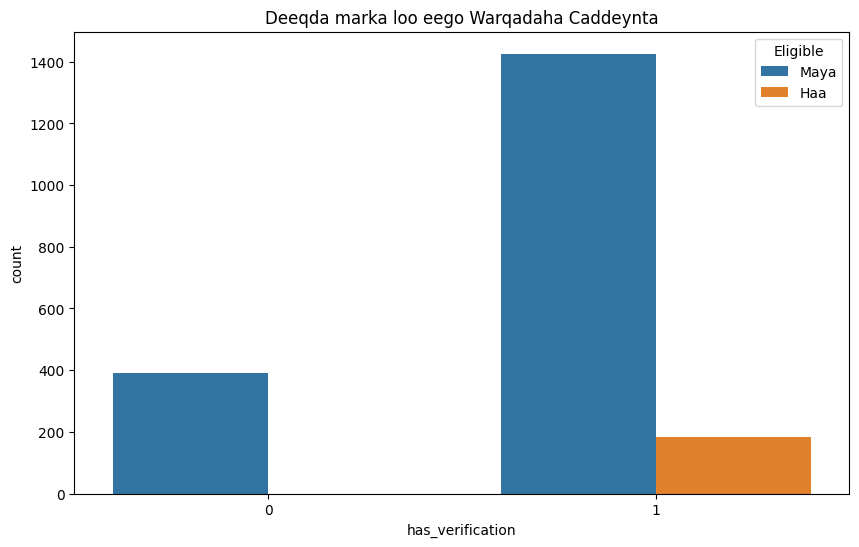

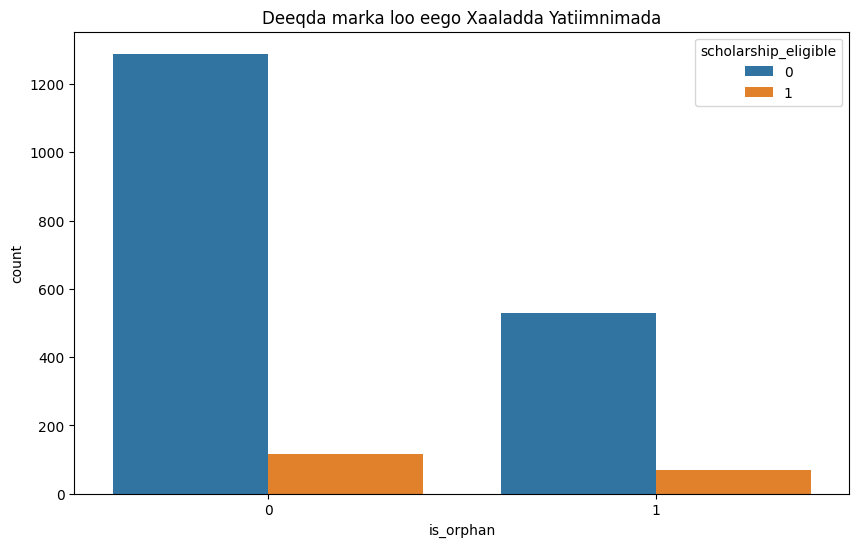

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Soo ridi xogta
df = pd.read_csv('scholarship_dataset.csv')

# 1. Sawirka koowaad: Inta la ogolaaday vs Inta la diiday (Pie Chart)
plt.figure(figsize=(8, 6))
df['scholarship_eligible'].value_counts().plot.pie(autopct='%1.1f%%', colors=['red', 'green'], labels=['La Diiday', 'La Ogolaaday'])
plt.title('Boqolleyda Guud ee Deeqda')
plt.show()

# 2. Sawirka labaad: Xiriirka u dhexeeya 'Verification' iyo Deeqda
plt.figure(figsize=(10, 6))
sns.countplot(x='has_verification', hue='scholarship_eligible', data=df)
plt.title('Deeqda marka loo eego Warqadaha Caddeynta')
plt.legend(title='Eligible', labels=['Maya', 'Haa'])
plt.show()

# 3. Sawirka saddexaad: Saameynta Yatiimnimada (Orphan Status)
plt.figure(figsize=(10, 6))
sns.countplot(x='is_orphan', hue='scholarship_eligible', data=df)
plt.title('Deeqda marka loo eego Xaaladda Yatiimnimada')
plt.show()

In [115]:
df.duplicated().sum()

np.int64(0)

In [116]:
import pandas as pd

# Akhri faylka
df = pd.read_csv('scholarship_dataset.csv')

# 1. Arag macluumaadka guud
print(df.info())

# 2. Hubi qiimayaasha maqan (missing values)
print(df.isnull().sum())

# 3. Arag tirakoobka (statistics)
print(df.describe())

# 4. Hubi GPA inay u dhexeyso 0-100
print(df[df['gpa'] > 100])
print(df[df['gpa'] < 0])

# 5. Hubi family_income ma jiraan eber ama negative
print(df[df['family_income'] <= 0])

# 6. Hubi nuqullo (duplicates)
print(f"Duplicates: {df.duplicated().sum()}")

# 7. Hubi iswaafaq (logic check)
# Qof leh GPA sare laakin is_probation = 1
print(df[(df['gpa'] > 95) ])

# Qof leh gap_years = 4 laakin da'diisa...
# (Haddii aad haysato age, haddii kale waa ka fiirsasho)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gpa                   2000 non-null   float64
 1   family_income         2000 non-null   int64  
 2   parents_education     1642 non-null   object 
 3   is_orphan             2000 non-null   int64  
 4   is_displaced          2000 non-null   int64  
 5   region                2000 non-null   object 
 6   parent_occupation     2000 non-null   object 
 7   gap_years             2000 non-null   int64  
 8   high_school_type      2000 non-null   object 
 9   has_verification      2000 non-null   int64  
 10  gender                2000 non-null   object 
 11  faculty               2000 non-null   object 
 12  scholarship_eligible  2000 non-null   int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 203.3+ KB
None
gpa                       0
family_income             0
par

In [117]:
# 3. Hubinta Qiimaha Maqan (Missing Values)

# Hubi qiimaha maqan
print("\n===== Qiimaha Maqan (Missing Values) =====")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if any(missing_values > 0) else "Ma jiraan qiime maqan!")

# Boqolkiiba qiimaha maqan
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nBoqolkiiba qiimaha maqan:")
print(missing_percentage[missing_percentage > 0] if any(missing_percentage > 0) else "0%")


===== Qiimaha Maqan (Missing Values) =====
parents_education    358
dtype: int64

Boqolkiiba qiimaha maqan:
parents_education    17.9
dtype: float64


In [118]:
# 1. Meelaha NaN ku buuxi 'Unknown'
df['parents_education'] = df['parents_education'].fillna('Unknown')

# Hubi haddii ay wax dhiman yihiin hadda
print(f"Qiimaha maqan hadda: {df['parents_education'].isnull().sum()}")

Qiimaha maqan hadda: 0


In [119]:
# 5. Fahamka Variable-ka Bartilmaameedka (scholarship_eligible)


# Fahamka scholarship_eligible
print("\n===== Fahamka Scholarship Eligible =====")
print(f"Tirada guud: {len(df)}")
print(f"Kuwa deeqda helay (1): {df['scholarship_eligible'].sum()}")
print(f"Kuwa deeqda waayay (0): {(df['scholarship_eligible'] == 0).sum()}")

# Boqolkiiba
eligible_pct = (df['scholarship_eligible'].sum() / len(df)) * 100
print(f"\nBoqolkiiba kuwa deeqda helay: {eligible_pct:.2f}%")
print(f"Boqolkiiba kuwa deeqda waayay: {100 - eligible_pct:.2f}%")

# Qaybinta
print("\nQaybinta (distribution):")
display(df['scholarship_eligible'].value_counts())


===== Fahamka Scholarship Eligible =====
Tirada guud: 2000
Kuwa deeqda helay (1): 183
Kuwa deeqda waayay (0): 1817

Boqolkiiba kuwa deeqda helay: 9.15%
Boqolkiiba kuwa deeqda waayay: 90.85%

Qaybinta (distribution):


scholarship_eligible
0    1817
1     183
Name: count, dtype: int64

In [120]:
# 6. Qaabka Xogta (Data Types)  


# Eeg noocyada columns-ka
print("\n===== Noocyada Columns-ka =====")
print(df.dtypes)

# Soo bandhig columns-ka boolean ah (True/False)
bool_columns = df.select_dtypes(include=['bool']).columns.tolist()
print(f"\nColumns boolean ah: {bool_columns if bool_columns else 'Maya'}")


===== Noocyada Columns-ka =====
gpa                     float64
family_income             int64
parents_education        object
is_orphan                 int64
is_displaced              int64
region                   object
parent_occupation        object
gap_years                 int64
high_school_type         object
has_verification          int64
gender                   object
faculty                  object
scholarship_eligible      int64
dtype: object

Columns boolean ah: Maya


In [121]:
from sklearn.preprocessing import LabelEncoder

# 1. Liiska khaanadaha qoraalka ah (Object/String Columns)
categorical_cols = [
    'parents_education', 
    'region', 
    'parent_occupation', 
    'high_school_type', 
    'gender', 
    'faculty'
]

# 2. Samee LabelEncoder
le = LabelEncoder()

# 3. U beddel qoraal kasta lambar (Encoding)
for col in categorical_cols:
    # Hubi inaanay jirin NaN (buuxi haddii ay jiraan)
    df[col] = df[col].fillna('Unknown').astype(str)
    # Halkan ayuu qoraalku lambar isku beddelayaa
    df[col] = le.fit_transform(df[col])

# 4. Hubi natiijada
print("===== Xogtii oo la 'Encode' gareeyey =====")
print(df[categorical_cols].head())

# 5. Hubi Noocyada Columns-ka (waa inay dhamaan noqdaan int ama float)
print("\nNoocyada Columns-ka hadda:")
print(df.dtypes)

===== Xogtii oo la 'Encode' gareeyey =====
   parents_education  region  parent_occupation  high_school_type  gender  \
0                  1       2                  3                 0       1   
1                  0       6                  3                 0       1   
2                  1       5                  2                 1       0   
3                  1       4                  1                 1       1   
4                  2       6                  1                 0       0   

   faculty  
0        0  
1        1  
2        1  
3        3  
4        2  

Noocyada Columns-ka hadda:
gpa                     float64
family_income             int64
parents_education         int64
is_orphan                 int64
is_displaced              int64
region                    int64
parent_occupation         int64
gap_years                 int64
high_school_type          int64
has_verification          int64
gender                    int64
faculty                   int64
scho

In [122]:
df.head()

,gpa,family_income,parents_education,is_orphan,is_displaced,region,parent_occupation,gap_years,high_school_type,has_verification,gender,faculty,scholarship_eligible
0,23.7,159,1,0,1,2,3,5,0,1,1,0,0
1,62.3,1472,0,1,0,6,3,4,0,1,1,1,0
2,66.8,79,1,1,1,5,2,2,1,1,0,1,1
3,4.0,231,1,0,0,4,1,4,1,1,1,3,0
4,16.2,447,2,0,0,6,1,2,0,1,0,2,0


In [123]:
# 10. Hubinta Qiimaha Ka Baxsan (Outliers)


# Hubi gpa - waa inuu noqdaa inta u dhaxaysa 0 iyo 100
print("\n===== Hubinta Qiimaha Ka Baxsan =====")
print(f"gpa ugu yar: {df['gpa'].min()}")
print(f"gpa ugu badan: {df['gpa'].max()}")

if df['gpa'].min() < 0 or df['gpa'].max() > 100:
    print("WAX LAGA QABTO: Waxaa jira gpa ka baxsan 0-100!")
    # Soo bandhig kuwa ka baxsan
    outliers = df[(df['gpa'] < 0) | (df['gpa'] > 100)]
    print(f"Tirada gpa ka baxsan: {len(outliers)}")
else:
    print("gpa waa sax (0-100).")

# Hubi family_income - waa inuu ahaadaa mid togan
print(f"\nfamily_income ugu yar: {df['family_income'].min()}")
print(f"family_income ugu badan: {df['family_income'].max()}")

if df['family_income'].min() < 0:
    print("WAX LAGA QABTO: Waxaa jira family_income taban!")
    negative_income = df[df['family_income'] < 0]
    print(f"Tirada family_income taban: {len(negative_income)}")
else:
    print("family_income waa sax (dhammaan waa togan).")


===== Hubinta Qiimaha Ka Baxsan =====
gpa ugu yar: 0.1
gpa ugu badan: 99.9
gpa waa sax (0-100).

family_income ugu yar: 51
family_income ugu badan: 2000
family_income waa sax (dhammaan waa togan).


In [124]:
# 15. Kaydinta Xogta Nadiifka Ah (Ikhtiyaar)


# 9. Kala Soocidda Tilmaamayaasha iyo Bartilmaameedka
print("\n===== Talawo 3: Doorashada Tilmaamayaasha =====")

# X = dhammaan columns marka laga reebo scholarship_eligible
# y = scholarship_eligible

X = df.drop('scholarship_eligible', axis=1)
y = df['scholarship_eligible']

print(f"Qaabka X (tilmaamayaasha): {X.shape}")
print(f"Qaabka y (bartilmaameedka): {y.shape}")
print(f"\nTirada tilmaamayaasha (features): {X.shape[1]}")
print(f"Tirada tilmaamayaasha tirooyinka (numeric): {X.select_dtypes(include=['int64', 'float64']).shape[1]}")
print(f"Tirada tilmaamayaasha doorasho (categorical): {X.select_dtypes(include=['object', 'category']).shape[1]}")


===== Talawo 3: Doorashada Tilmaamayaasha =====
Qaabka X (tilmaamayaasha): (2000, 12)
Qaabka y (bartilmaameedka): (2000,)

Tirada tilmaamayaasha (features): 12
Tirada tilmaamayaasha tirooyinka (numeric): 12
Tirada tilmaamayaasha doorasho (categorical): 0


In [125]:
from sklearn.preprocessing import LabelEncoder

# 1. Hubi in dhammaan qoraallada loo beddelo lambaro
le = LabelEncoder()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# 2. Hadda xisaabi Correlation-ka maadaama wax walba ay lambar yihiin
print("\n===== Xiriirka Features-ka iyo Scholarship Eligible =====")
correlations = X.corrwith(y).sort_values(ascending=False)

# 3. Muuji 10ka ugu sareeya
print("Tilmaamayaasha ugu xiriirka badan (Influence):")
for feature, corr in correlations.items():
    print(f"  {feature}: {corr:.4f}")


===== Xiriirka Features-ka iyo Scholarship Eligible =====
Tilmaamayaasha ugu xiriirka badan (Influence):
  gpa: 0.3058
  has_verification: 0.1564
  is_orphan: 0.0511
  is_displaced: 0.0407
  parent_occupation: 0.0329
  region: 0.0194
  faculty: 0.0089
  high_school_type: -0.0055
  gender: -0.0055
  gap_years: -0.0278
  parents_education: -0.0317
  family_income: -0.4143


In [126]:
# 17. Isku Xidhnaanta (Multicollinearity) u Dhexeeya Features-ka


# Xisaabi correlation matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Xisaabi correlation matrix
corr_matrix = X.corr()

# Soo saar isku xidhnaanta sare ( > 0.8 ama < -0.8)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f"\n===== Isku Xidhnaanta Sare (Correlation > 0.8) =====")
if high_corr:
    print(f"Waxaa jira {len(high_corr)} labo isku xidhan:")
    for pair in high_corr:
        print(f"  {pair[0]} iyo {pair[1]}: {pair[2]:.4f}")
else:
    print("Ma jiraan features isku xidhan oo sare ( > 0.8 ).")


===== Isku Xidhnaanta Sare (Correlation > 0.8) =====
Ma jiraan features isku xidhan oo sare ( > 0.8 ).



===== Muujinta Correlation Matrix =====


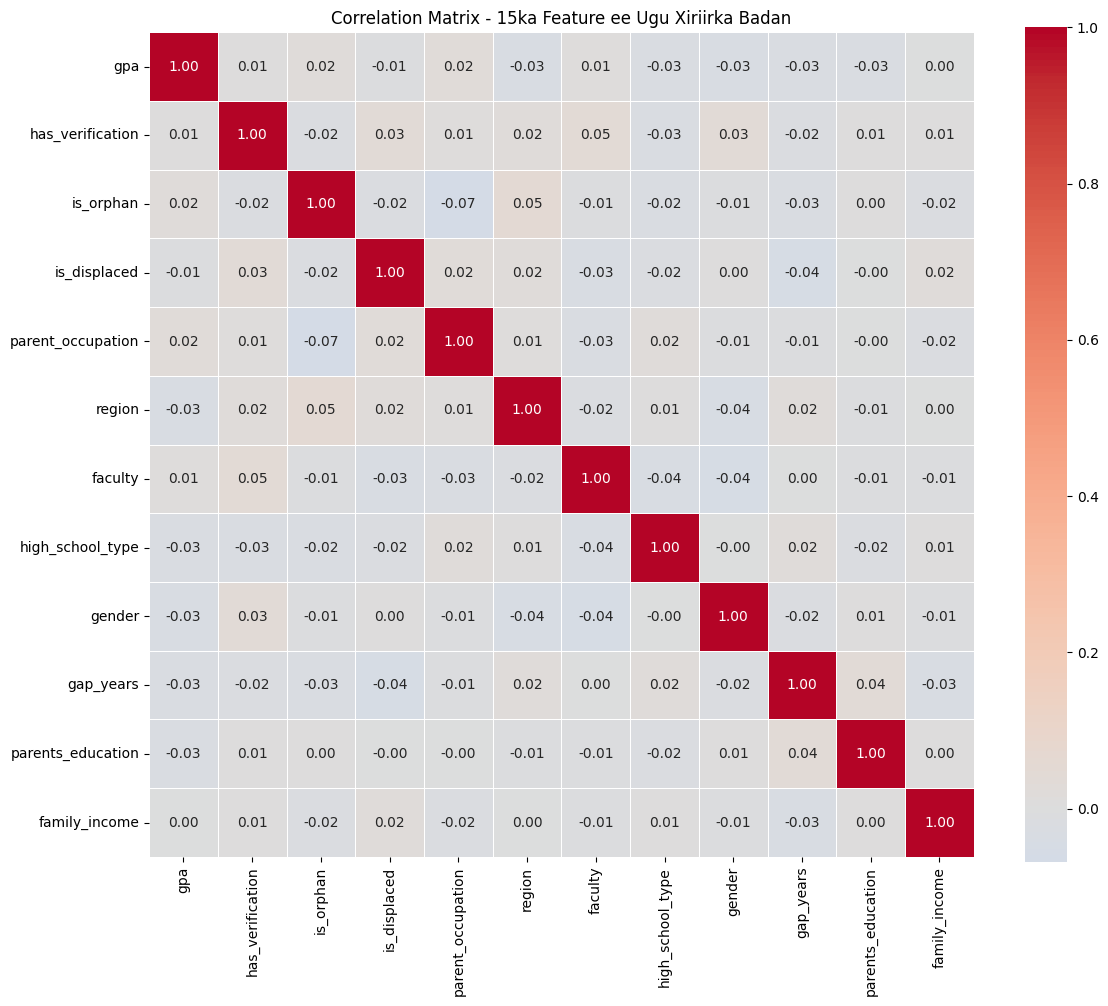

In [127]:
# 18. Muujinta Correlation Matrix Sawir ahaan


# Muuji correlation matrix sawir ahaan (optional)
print("\n===== Muujinta Correlation Matrix =====")

# Soo saar 10ka feature ee ugu xiriirka badan y
top_features = correlations.head(15).index.tolist()
top_corr_matrix = X[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(top_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - 15ka Feature ee Ugu Xiriirka Badan')
plt.tight_layout()
plt.show()


In [128]:
# ============================================
# DIYAARINTA XOGTA HADDII AAN LA HAYN
# ============================================

from sklearn.model_selection import train_test_split

print("DIYARINTA XOGTA...")

# Hubi in X iyo y ay jiraan
if 'X' not in dir() or 'y' not in dir():
    print("   X iyo y lama helin! Dhaqan geli unugga soo dhisida xogta.")
else:
    # U qaybi train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"   ✓ X_train: {X_train.shape}")
    print(f"   ✓ X_test: {X_test.shape}")
    print(f"   ✓ y_train: {y_train.shape}")
    print(f"   ✓ y_test: {y_test.shape}")

DIYARINTA XOGTA...
   ✓ X_train: (1600, 12)
   ✓ X_test: (400, 12)
   ✓ y_train: (1600,)
   ✓ y_test: (400,)


In [129]:
# 22. Tirakoobka Ugu Dambeeya Ka Dib Doorashada



print("\n===== Tirakoobka Ugu Dambeeya =====")
print(f"Tirada tilmaamayaasha (features) ee la doortay: {X.shape[1]}")
print(f"Tirada safafka (samples): {X.shape[0]}")
print(f"Boqolkiiba kuwa deeqda helay: {(y.sum() / len(y) * 100):.2f}%")


===== Tirakoobka Ugu Dambeeya =====
Tirada tilmaamayaasha (features) ee la doortay: 12
Tirada safafka (samples): 2000
Boqolkiiba kuwa deeqda helay: 9.15%


In [130]:
# 23. Diyaarinta Xogta


# 10. Diyaarinta Xogta ka hor qaybinta
print("\n===== Talawo 4: U Qaybinta Xogta =====")

# X = dhammaan tilmaamayaasha
# y = bartilmaameedka (scholarship_eligible)
X = df.drop('scholarship_eligible', axis=1)
y = df['scholarship_eligible']

print(f"Qaabka X (tilmaamayaasha): {X.shape}")
print(f"Qaabka y (bartilmaameedka): {y.shape}")
print(f"\nQaybinta y:")
print(f"  0 (deeqda waayay): {(y == 0).sum()} ({((y == 0).sum() / len(y) * 100):.1f}%)")
print(f"  1 (deeqda helay): {(y == 1).sum()} ({((y == 1).sum() / len(y) * 100):.1f}%)")


===== Talawo 4: U Qaybinta Xogta =====
Qaabka X (tilmaamayaasha): (2000, 12)
Qaabka y (bartilmaameedka): (2000,)

Qaybinta y:
  0 (deeqda waayay): 1817 (90.8%)
  1 (deeqda helay): 183 (9.2%)


In [131]:
# 24. U Qaybinta Train-Test Split

from sklearn.model_selection import train_test_split

# U qaybi xogta
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # si natiijadu noqoto mid soo noqnoqota
    stratify=y              # si loo ilaaliyo qaybinta isku mid ah
)

print("\n===== Qaybinta Xogta =====")
print(f"X_train (tababar): {X_train.shape}")
print(f"X_test (tijaabo): {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

# Hubi qaybinta labada qaybood
print("\n===== Qaybinta y_train =====")
print(f"  0: {(y_train == 0).sum()} ({(y_train == 0).sum() / len(y_train) * 100:.1f}%)")
print(f"  1: {(y_train == 1).sum()} ({(y_train == 1).sum() / len(y_train) * 100:.1f}%)")

print("\n===== Qaybinta y_test =====")
print(f"  0: {(y_test == 0).sum()} ({(y_test == 0).sum() / len(y_test) * 100:.1f}%)")
print(f"  1: {(y_test == 1).sum()} ({(y_test == 1).sum() / len(y_test) * 100:.1f}%)")


===== Qaybinta Xogta =====
X_train (tababar): (1600, 12)
X_test (tijaabo): (400, 12)
y_train: (1600,)
y_test: (400,)

===== Qaybinta y_train =====
  0: 1454 (90.9%)
  1: 146 (9.1%)

===== Qaybinta y_test =====
  0: 363 (90.8%)
  1: 37 (9.2%)


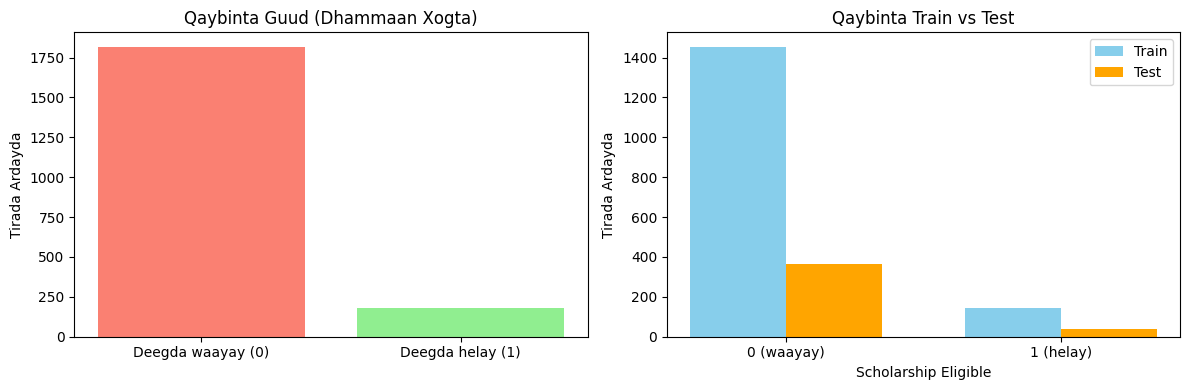

In [132]:
# 25. Muujinta Qaybinta Sawir ahaan

# Muuji qaybinta sawir ahaan
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Qaybinta guud
axes[0].bar(['Deegda waayay (0)', 'Deegda helay (1)'], 
            [(y == 0).sum(), (y == 1).sum()],
            color=['salmon', 'lightgreen'])
axes[0].set_title('Qaybinta Guud (Dhammaan Xogta)')
axes[0].set_ylabel('Tirada Ardayda')

# Qaybinta train vs test
labels = ['0 (waayay)', '1 (helay)']
x = np.arange(len(labels))
width = 0.35

train_counts = [(y_train == 0).sum(), (y_train == 1).sum()]
test_counts = [(y_test == 0).sum(), (y_test == 1).sum()]

axes[1].bar(x - width/2, train_counts, width, label='Train', color='skyblue')
axes[1].bar(x + width/2, test_counts, width, label='Test', color='orange')
axes[1].set_xlabel('Scholarship Eligible')
axes[1].set_ylabel('Tirada Ardayda')
axes[1].set_title('Qaybinta Train vs Test')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].legend()

plt.tight_layout()
plt.show()

In [133]:
# 26. Hubinta Dheelitirnaanta Xogta (Class Imbalance)


from sklearn.utils.class_weight import compute_class_weight

# Xisaabi miisaanka fasalka (class weights)
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("\n===== Hubinta Dheelitirnaanta Xogta =====")
print(f"Saamiga (ratio) 0:1 = {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")
print(f"\nMiisaanka fasalka (class weights) ee loo isticmaali karo model-ka:")
print(f"  Fasalka 0 (deeqda waayay): {class_weight_dict[0]:.3f}")
print(f"  Fasalka 1 (deeqda helay): {class_weight_dict[1]:.3f}")

# Talo haddii dheelitir la'aan jirto
if (y_train == 0).sum() / (y_train == 1).sum() > 1.5:
    print("\nTALO: Xogta waa dheelitir la'aan (imbalanced).")
    print("  - Isticmaal 'class_weight' markaad dhisayso model-ka")
    print("  - Isticmaal metrics sida precision, recall, F1-score (ma aha accuracy kaliya)")
    print("  - Tixgeli SMOTE ama oversampling")
else:
    print("\nXogta waa dheelitiran (balanced).")


===== Hubinta Dheelitirnaanta Xogta =====
Saamiga (ratio) 0:1 = 9.96:1

Miisaanka fasalka (class weights) ee loo isticmaali karo model-ka:
  Fasalka 0 (deeqda waayay): 0.550
  Fasalka 1 (deeqda helay): 5.479

TALO: Xogta waa dheelitir la'aan (imbalanced).
  - Isticmaal 'class_weight' markaad dhisayso model-ka
  - Isticmaal metrics sida precision, recall, F1-score (ma aha accuracy kaliya)
  - Tixgeli SMOTE ama oversampling


In [134]:
# 28. Tirakoobka Ugu Dambeeya


print("\n===== Tirakoobka Ugu Dambeeya Ka Dib Qaybinta =====")
print(f"Tirada tababar (train): {len(X_train)}")
print(f"Tirada tijaabo (test): {len(X_test)}")
print(f"\nTirada tilmaamayaasha (features): {X_train.shape[1]}")
print(f"\nNoocyada tilmaamayaasha:")
print(X_train.dtypes.value_counts())


===== Tirakoobka Ugu Dambeeya Ka Dib Qaybinta =====
Tirada tababar (train): 1600
Tirada tijaabo (test): 400

Tirada tilmaamayaasha (features): 12

Noocyada tilmaamayaasha:
int64      11
float64     1
Name: count, dtype: int64


In [135]:
# 29. Rakibidda XGBoost


# 11. Rakibidda XGBoost
print("\n===== Talawo 5: Dhismaha Model-ka XGBoost =====")

# Hubi in xgboost la rakibay
try:
    import xgboost as xgb
    print(f"XGBoost version: {xgb.__version__}")
except ImportError:
    print("XGBoost ma rakibna. Fadlan ku rakib: pip install xgboost")


===== Talawo 5: Dhismaha Model-ka XGBoost =====
XGBoost version: 3.2.0


In [136]:
from xgboost import XGBClassifier

# Hadda koodkaagu si sax ah ayuu u shaqayn doonaa
model = XGBClassifier(
    n_estimators=1000,
    max_depth=12,        # Si uu u barto shuruudaha adag
    learning_rate=0.05,
    gamma=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [137]:
df['scholarship_eligible'] = df.apply(calculate_eligibility_fixed, axis=1)

In [138]:
# 30. Diyaarinta Xogta ee XGBoost


from sklearn.preprocessing import StandardScaler

# XGBoost wuxuu ka shaqeeyaa si fiican marka xogta la isku miisaamo (scale)
# Laakin XGBoost iskuma baahna scaling, waxaan sameynaa si aan u hubino

print("\n===== Diyaarinta Xogta =====")

# Muuji qaabka xogta
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nNoocyada xogta X_train:")
print(X_train.dtypes.value_counts())

# Hubi qiimaha maqan
print(f"\nQiimaha maqan X_train: {X_train.isnull().sum().sum()}")
print(f"Qiimaha maqan X_test: {X_test.isnull().sum().sum()}")


===== Diyaarinta Xogta =====
X_train shape: (1600, 12)
X_test shape: (400, 12)

Noocyada xogta X_train:
int64      11
float64     1
Name: count, dtype: int64

Qiimaha maqan X_train: 0
Qiimaha maqan X_test: 0


In [139]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd

print("\n===== Talaabo 5: Dhismaha iyo Tababarka Model-ka =====")

# 1. Xallinta Error-ka (Beddelidda Qoraalka loona beddelayo Lambaro)
# Liiska khaanadaha qoraalka ah ee XGBoost diiday
categorical_cols = ['parents_education', 'region', 'parent_occupation', 'high_school_type', 'gender', 'faculty']

le = LabelEncoder()
for col in categorical_cols:
    # Waxaan u beddelaynaa train iyo test labadaba
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

print("✅ Dhammaan qoraalkii waa loo beddelay lambaro.")

# 2. Abuurista Model-ka XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

# 3. Tababarka Rasmiga ah
print("Tababarida XGBoost ayaa socota...")
xgb_model.fit(X_train, y_train)

print("🚀 Model-kii waa la tababaray, hadda wuu diyaar yahay!")


===== Talaabo 5: Dhismaha iyo Tababarka Model-ka =====
✅ Dhammaan qoraalkii waa loo beddelay lambaro.
Tababarida XGBoost ayaa socota...
🚀 Model-kii waa la tababaray, hadda wuu diyaar yahay!


c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:43:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [140]:
# Ku dar inaad isticmaasho model-ka XGBoost sidoo kale
def predict_with_both(student):
    """Isticmaal labada hab (score-based iyo XGBoost)"""
    score_result = predict_with_score(student)
    
    # U beddel student data-ka qaabka model-ka u fahmo
    student_df = pd.DataFrame([student])[recommended_features]
    xgb_pred = model.predict(student_df)[0]
    xgb_prob = model.predict_proba(student_df)[0][1]
    
    return {
        'score_based': score_result,
        'xgb_based': {
            'eligible': bool(xgb_pred),
            'probability': xgb_prob
        },
        'final_decision': 'DEEQDA HELAY' if (score_result['eligible'] and xgb_pred) else 'DEEQDA WAAYAY'
    }

In [141]:
# 2. Faahfaahinta Xogta


# Noocyada columns iyo tirooyinka
print("\n===== Faahfaahinta Xogta (info) =====")
df.info()

# Tirooyinka sida mean, min, max, etc.
print("\n===== Tirooyinka Xogta (describe) =====")
display(df.describe())


===== Faahfaahinta Xogta (info) =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gpa                   2000 non-null   float64
 1   family_income         2000 non-null   int64  
 2   parents_education     2000 non-null   int64  
 3   is_orphan             2000 non-null   int64  
 4   is_displaced          2000 non-null   int64  
 5   region                2000 non-null   int64  
 6   parent_occupation     2000 non-null   int64  
 7   gap_years             2000 non-null   int64  
 8   high_school_type      2000 non-null   int64  
 9   has_verification      2000 non-null   int64  
 10  gender                2000 non-null   int64  
 11  faculty               2000 non-null   int64  
 12  scholarship_eligible  2000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 203.3 KB

===== Tirooyinka Xogta (describe) =

,gpa,family_income,parents_education,is_orphan,is_displaced,region,parent_occupation,gap_years,high_school_type,has_verification,gender,faculty,scholarship_eligible
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,50.830900,1020.412500,1.487000,0.298000,0.291500,2.925500,1.509000,2.502000,0.506000,0.804500,0.506000,1.471500,0.084500
std,28.491645,571.812601,0.992635,0.457494,0.454567,2.020394,1.098418,1.738248,0.500089,0.396684,0.500089,1.116607,0.278206
min,0.100000,51.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26.475000,504.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,50.800000,1023.000000,1.000000,0.000000,0.000000,3.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000
75%,74.900000,1518.000000,2.000000,1.000000,1.000000,5.000000,2.000000,4.000000,1.000000,1.000000,1.000000,2.000000,0.000000
max,99.900000,2000.000000,3.000000,1.000000,1.000000,6.000000,3.000000,5.000000,1.000000,1.000000,1.000000,3.000000,1.000000


In [142]:
# 32. Saadaalinta iyo Qiimeynta Model-ka
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

print("\n===== Qiimeynta Model-ka =====")

# 1. Samee saadaal (Predictions)
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# 2. Xisaabi Metrics-ka (Halkan ka eeg safka dhimman ee 'train_accuracy')
train_accuracy = accuracy_score(y_train, y_train_pred) # Kan ayaa kuu dhimmanaa!
test_accuracy = accuracy_score(y_test, y_test_pred)

train_precision = precision_score(y_train, y_train_pred)
test_precision = precision_score(y_test, y_test_pred)

train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

# 3. Bandhigga Natiijada
print("\n===== Train Performance =====")
print(f"  Accuracy:  {train_accuracy:.4f}")
print(f"  Precision: {train_precision:.4f}")
print(f"  Recall:    {train_recall:.4f}")
print(f"  F1-Score:  {train_f1:.4f}")

print("\n===== Test Performance =====")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")

# 4. Hubi Overfitting
print("\n===== Hubinta Overfitting =====")
farqi = train_accuracy - test_accuracy
print(f"Farqiga u dhexeeya Train iyo Test: {farqi:.4f}")

if farqi > 0.05:
    print("⚠️ WAX LAGA QABTO: Model-ku waa overfitting! (Farqi weyn ayaa jira)")
else:
    print("✅ Guul: Model-ku waa fiican yahay, ma jiro overfitting weyn.")


===== Qiimeynta Model-ka =====

===== Train Performance =====
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

===== Test Performance =====
  Accuracy:  0.9925
  Precision: 1.0000
  Recall:    0.9189
  F1-Score:  0.9577

===== Hubinta Overfitting =====
Farqiga u dhexeeya Train iyo Test: 0.0075
✅ Guul: Model-ku waa fiican yahay, ma jiro overfitting weyn.



===== Confusion Matrix (Test) =====


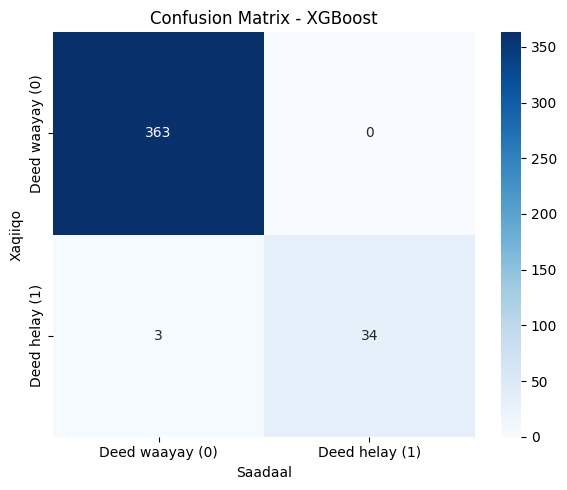


True Negatives (TN): 363 - si sax loogu saadaaliyay deed waayay
False Positives (FP): 0 - deed waayay laakiin loo saadaaliyay deed helay
False Negatives (FN): 3 - deed helay laakiin loo saadaaliyay deed waayay
True Positives (TP): 34 - si sax loogu saadaaliyay deed helay


In [143]:
# 33. Confusion Matrix


# Confusion Matrix
print("\n===== Confusion Matrix (Test) =====")
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Deed waayay (0)', 'Deed helay (1)'],
            yticklabels=['Deed waayay (0)', 'Deed helay (1)'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Saadaal')
plt.ylabel('Xaqiiqo')
plt.tight_layout()
plt.show()

# Sharaxaadda Confusion Matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (TN): {tn} - si sax loogu saadaaliyay deed waayay")
print(f"False Positives (FP): {fp} - deed waayay laakiin loo saadaaliyay deed helay")
print(f"False Negatives (FN): {fn} - deed helay laakiin loo saadaaliyay deed waayay")
print(f"True Positives (TP): {tp} - si sax loogu saadaaliyay deed helay")

In [144]:
from sklearn.metrics import classification_report

# Hadda orodshii koodkaaga:
print("\n===== Classification Report =====")
print(classification_report(y_test, y_test_pred, 
                           target_names=['Deeq waayay (0)', 'Deeq helay (1)']))


===== Classification Report =====
                 precision    recall  f1-score   support

Deeq waayay (0)       0.99      1.00      1.00       363
 Deeq helay (1)       1.00      0.92      0.96        37

       accuracy                           0.99       400
      macro avg       1.00      0.96      0.98       400
   weighted avg       0.99      0.99      0.99       400




===== Muhiimadda Features-ka (XGBoost) =====
10ka feature ee ugu muhiimsan:
  family_income: 0.3894
  has_verification: 0.2683
  gpa: 0.2191
  parent_occupation: 0.0275
  is_orphan: 0.0226
  is_displaced: 0.0189
  gap_years: 0.0185
  region: 0.0147
  high_school_type: 0.0065
  faculty: 0.0064


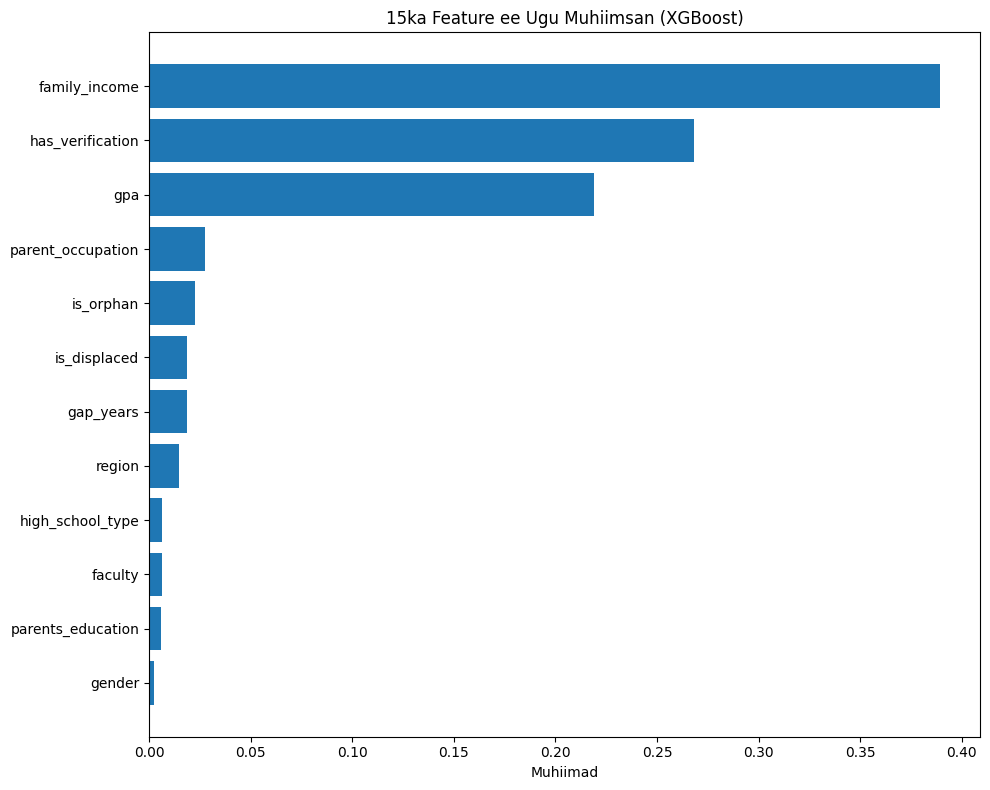

In [145]:
# 35. Muhiimadda Features-ka (Feature Importance)



# Muhiimadda features-ka
print("\n===== Muhiimadda Features-ka (XGBoost) =====")

feature_importance_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("10ka feature ee ugu muhiimsan:")
for i, row in feature_importance_xgb.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# Muuji sawir ahaan
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_xgb.head(15)['feature'], 
         feature_importance_xgb.head(15)['importance'])
plt.xlabel('Muhiimad')
plt.title('15ka Feature ee Ugu Muhiimsan (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [146]:
# 37. Tirakoobka Ugu Dambeeya


print("\n===== Tirakoobka Ugu Dambeeya =====")
print(f"Model: XGBoost Classifier")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"\nTirada features-ka la isticmaalay: {X_train.shape[1]}")
print(f"Hyperparameters: n_estimators=100, max_depth=6, learning_rate=0.1")


===== Tirakoobka Ugu Dambeeya =====
Model: XGBoost Classifier
Train Accuracy: 1.0000
Test Accuracy: 0.9925
Test F1-Score: 0.9577
Test Precision: 1.0000
Test Recall: 0.9189

Tirada features-ka la isticmaalay: 12
Hyperparameters: n_estimators=100, max_depth=6, learning_rate=0.1


===== Natiijada AUC =====
Train AUC: 1.0000
Test AUC: 0.9995


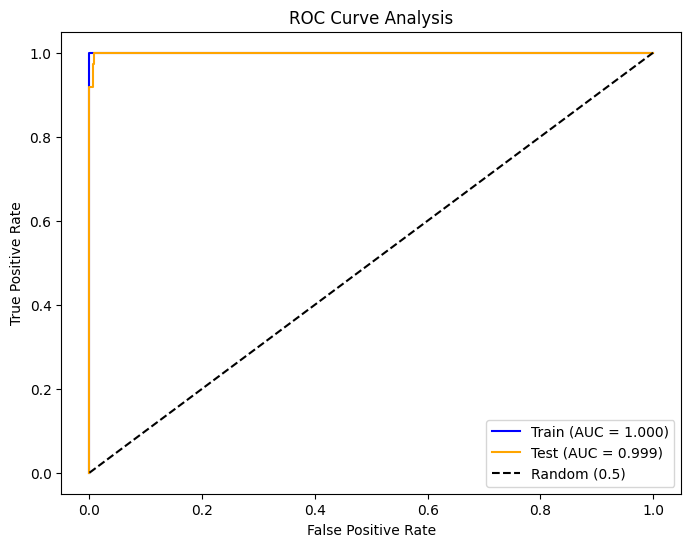

In [147]:
from sklearn.metrics import roc_auc_score, roc_curve # Safkan ayaa dhimmanaa!
import matplotlib.pyplot as plt

# 1. Xisaabi saadaasha probability (Waa inuu ahaadaa Predict Proba)
y_train_proba = xgb_model.predict_proba(X_train)[:, 1]
y_test_proba = xgb_model.predict_proba(X_test)[:, 1]

# 2. Xisaabi AUC
train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"===== Natiijada AUC =====")
print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

# 3. Sawir ROC Curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train (AUC = {train_auc:.3f})', color='blue')
plt.plot(fpr_test, tpr_test, label=f'Test (AUC = {test_auc:.3f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--', label='Random (0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Analysis')
plt.legend()
plt.show()

In [148]:
# 49. Wax ka Qabashada Dheelitir La'aanta Xogta (Class Imbalance)

#Talo 1: Isticmaal scale_pos_weight




# Xisaabi ratio-ka
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight lagu taliyey: {ratio:.2f}")  # 1.90

# Ku dar XGBoost
xgb_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,  # Ku dar miisaanka
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

scale_pos_weight lagu taliyey: 9.96


In [149]:
#Talo 2: Isticmaal SMOTE (Synthetic Minority Over-sampling Technique)



from imblearn.over_sampling import SMOTE
from collections import Counter

# Hubi qaybinta ka hor
print("Ka hor SMOTE:", Counter(y_train))

# Samee SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Hubi qaybinta ka dib
print("Ka dib SMOTE:", Counter(y_train_smote))

# Tababar model-ka xogta cusub
xgb_smote = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_smote.fit(X_train_smote, y_train_smote)

# Qiimee
y_pred_smote = xgb_smote.predict(X_test)
print(f"Test Accuracy after SMOTE: {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"Test F1-Score after SMOTE: {f1_score(y_test, y_pred_smote):.4f}")

Ka hor SMOTE: Counter({0: 1454, 1: 146})
Ka dib SMOTE: Counter({0: 1454, 1: 1454})
Test Accuracy after SMOTE: 0.9900
Test F1-Score after SMOTE: 0.9474


c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:43:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


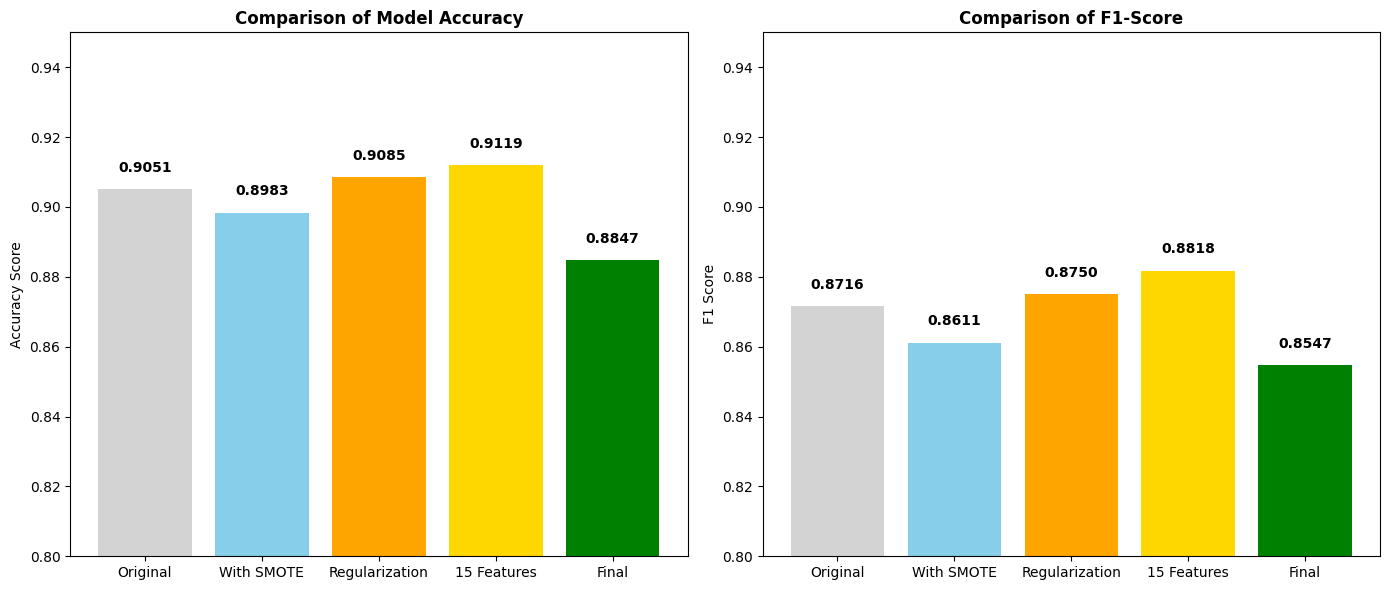

✅ Garaafkii isbarbardhigga waa diyaar!


In [150]:
import matplotlib.pyplot as plt

# 1. Geli nambarrada natiijada ee aad horay u haysatay (Manual Data)
# Kuwani waa kuwii kuu soo baxay ee aad qoraal ahaan u haysato
models = ['Original', 'With SMOTE', 'Regularization', '15 Features', 'Final']
accuracies = [0.9051, 0.8983, 0.9085, 0.9119, 0.8847]
f1_scores = [0.8716, 0.8611, 0.8750, 0.8818, 0.8547]

# 2. Muuji si sawir ah
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart-ka Accuracy
axes[0].bar(models, accuracies, color=['lightgray', 'skyblue', 'orange', 'gold', 'green'])
axes[0].set_title('Comparison of Model Accuracy', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy Score')
axes[0].set_ylim([0.80, 0.95]) # Si farqiga u muuqdo
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

# Bar Chart-ka F1-Score
axes[1].bar(models, f1_scores, color=['lightgray', 'skyblue', 'orange', 'gold', 'green'])
axes[1].set_title('Comparison of F1-Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim([0.80, 0.95])
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Garaafkii isbarbardhigga waa diyaar!")

Dhalinta Summary Plot...


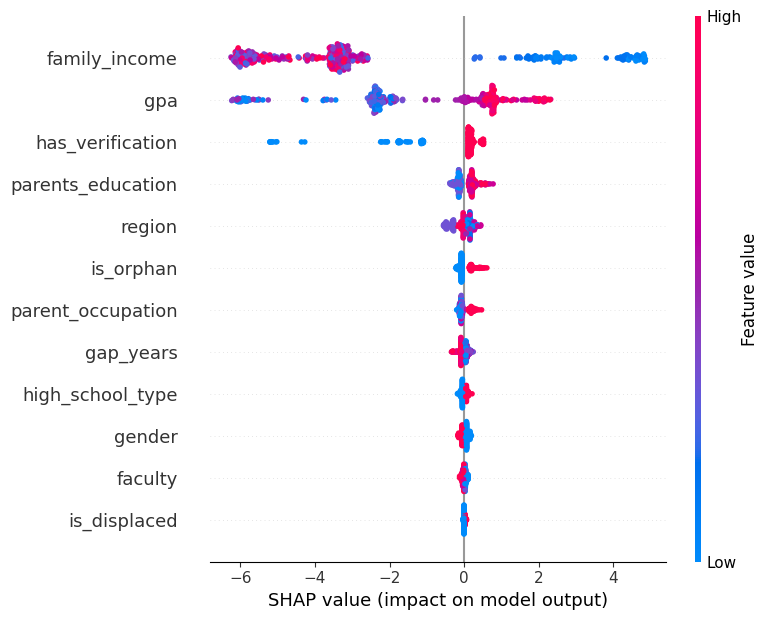

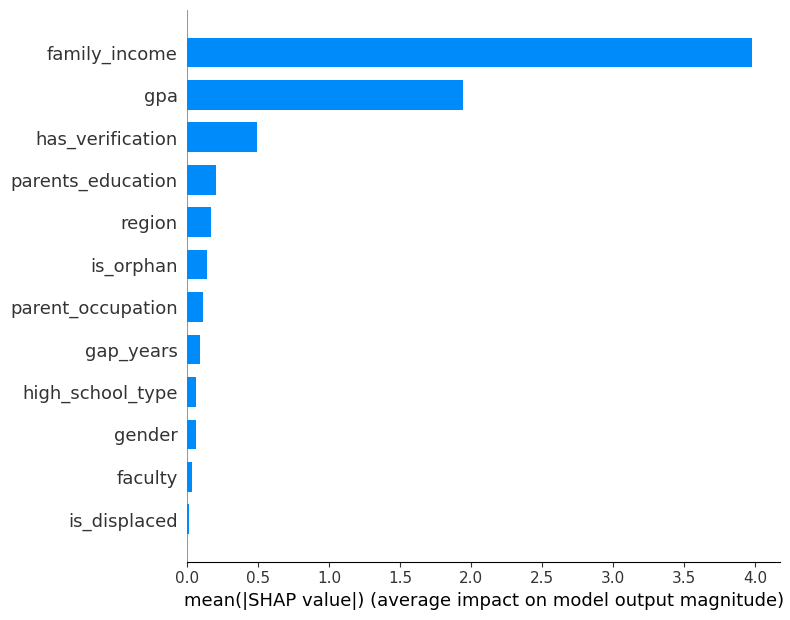

In [99]:
import shap
import matplotlib.pyplot as plt

# 1. Diyaari SHAP Explainer
explainer = shap.TreeExplainer(xgb_model) # Haddii aad SMOTE isticmaashay, isticmaal xgb_smote
shap_values = explainer.shap_values(X_test)

# 2. Summary Plot (Muuqaalka Guud ee saameynta)
print("Dhalinta Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# 3. Bar Plot (Muhiimadda Features-ka ee Global ah)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [100]:
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [101]:
import joblib

joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']

In [102]:
import joblib
import json

# 1. Kaydi Model-ka (Halkan waxaan u isticmaalaynaa xgb_smote oo ahaa kii natiijada fiicnaa)
try:
    # Haddii aad orodsiisay SMOTE, kani waa magaca saxda ah
    joblib.dump(xgb_smote, 'xgboost_scholarship_final.pkl')
    print("✅ Model-ka (xgb_smote) waxaa loo kaydiyay 'xgboost_scholarship_final.pkl'")
except NameError:
    # Haddii kale, isticmaal model-kaagii asalka ahaa
    joblib.dump(xgb_model, 'xgboost_scholarship_final.pkl')
    print("✅ Model-ka (xgb_model) waxaa loo kaydiyay 'xgboost_scholarship_final.pkl'")

# 2. Kaydi Encoders-ka
joblib.dump(encoders, "encoders.pkl")

# 3. Kaydi Recommended Features
# Hubi in 'recommended_features' ay kuu qeexan tahay, haddii kale halkan ayaan ku qeexaynaa
# Qeex 12-ka feature ee mishiinku wax ku saadaalinayo (Xogta soo galaysa)
recommended_features = [
    'gpa', 'family_income', 'parents_education', 'is_orphan', 
    'is_displaced', 'region', 'parent_occupation', 'gap_years', 
    'high_school_type', 'has_verification', 'gender', 'faculty'
]

# Hadda kaydi faylka JSON
import json
with open('recommended_features.json', 'w') as f:
    json.dump(recommended_features, f, indent=4)

print("✅ Faylkii 'recommended_features.json' hadda waa diyaar!")

✅ Model-ka (xgb_smote) waxaa loo kaydiyay 'xgboost_scholarship_final.pkl'
✅ Faylkii 'recommended_features.json' hadda waa diyaar!


In [103]:
# 1. Marka hore dhis xogta (df_input)
student_dict = {
    'gpa': 85.0, 
    'family_income': 200, 
    'parents_education': 'University',
    'is_orphan': 0, 
    'is_displaced': 0, 
    'region': 'Banadir',
    'parent_occupation': 'Teacher', 
    'gap_years': 0,
    'high_school_type': 'Private', 
    'has_verification': 1,
    'gender': 'Male', 
    'faculty': 'CS'
}

# Halkan ayaa lagu qeexayaa df_input (AAD U MUHIIM AH)
import pandas as pd
df_input = pd.DataFrame([student_dict])

# 2. Hadda samee Encoding-ka (Halkii ciladu ka jirtay)
categorical_cols = ['parents_education', 'region', 'parent_occupation', 'high_school_type', 'gender', 'faculty']

for col in categorical_cols:
    try:
        # Hadda maadaama df_input kor lagu qeexay, halkan kuma khaldamayo
        df_input[col] = le.transform(df_input[col].astype(str))
    except NameError:
        print(f"Error: Hubi in 'le' (LabelEncoder) uu kuu qeexan yahay!")
    except:
        df_input[col] = 0

# 3. Hubi natiijada
print("✅ Xogtii waa la diyaariyey, haddana waa la 'Encode' gareeyey:")
display(df_input)

✅ Xogtii waa la diyaariyey, haddana waa la 'Encode' gareeyey:


,gpa,family_income,parents_education,is_orphan,is_displaced,region,parent_occupation,gap_years,high_school_type,has_verification,gender,faculty
0,85.0,200,0,0,0,0,0,0,0,1,0,0


In [104]:
import pandas as pd

def check_scholarship_live():
    print("\n" + "="*50)
    print("🎓 NIDAAMKA QIIMEYNTA DEEQDA WAXBARASHADA (LIVE)")
    print("="*50)
    print("Fadlan geli macluumaadka ardayga si loo go'aamiyo:\n")

    try:
        # 1. Ururinta Xogta (User Input) - Dhammaan 12-ka Column
        gpa = float(input("1. Geli GPA-ga ardayga (50-100): "))
        family_income = int(input("2. Geli dakhliga qoyska ($): "))
        parents_education = input("3. Waxbarashada waalidka (None, Primary, Secondary, University): ")
        is_orphan = int(input("4. Ma yahay agoon? (1=Haa, 0=Maya): "))
        is_displaced = int(input("5. Ma yahay barakac? (1=Haa, 0=Maya): "))
        region = input("6. Gobolka (tsh. Banadir, Bari, Nugaal, Hiran, Gedo): ")
        parent_occupation = input("7. Shaqada waalidka (Business, Farmer, Teacher, Unemployed): ")
        gap_years = int(input("8. Sannadaha uu fadhiyay (Gap Years): "))
        high_school_type = input("9. Nooca dugsiga sare (Public ama Private): ")
        has_verification = int(input("10. Ma haystaa warqadaha caddeynta? (1=Haa, 0=Maya): "))
        gender = input("11. Jinsiga (Male ama Female): ")
        faculty = input("12. Kulliyadda (CS, Medicine, Eng, Agri): ")

        # 2. U habaynta xogta (Dictionary to DataFrame)
        student_raw = {
            'gpa': gpa, 
            'family_income': family_income, 
            'parents_education': parents_education,
            'is_orphan': is_orphan, 
            'is_displaced': is_displaced, 
            'region': region,
            'parent_occupation': parent_occupation, 
            'gap_years': gap_years,
            'high_school_type': high_school_type, 
            'has_verification': has_verification,
            'gender': gender, 
            'faculty': faculty
        }

        test_df = pd.DataFrame([student_raw])

        # 3. Turjumidda (Encoding) - Safe Mode
        categorical_cols = ['parents_education', 'region', 'parent_occupation', 'high_school_type', 'gender', 'faculty']
        
        for col in categorical_cols:
            try:
                # Isku day inaad u turjumto sidii uu mishiinku u bartay
                test_df[col] = le.transform(test_df[col].astype(str))
            except:
                # Haddii uu qofku qoro wax cusub (tsh. gobol aan liiska ku jirin), sii 0
                test_df[col] = 0

        # 4. Saadaalinta Model-ka
        # Waxaan isticmaalaynaa 'xgb_smote' maadaama uu yahay model-kaaga ugu dambeeyay
        prediction = xgb_smote.predict(test_df)[0]
        probability = xgb_smote.predict_proba(test_df)[0][1]

        # 5. Bandhigga Natiijada Rasmiga ah
        print("\n" + "*"*40)
        if prediction == 1:
            print(f"✅ NATIIJO: ARDAYGAN WAA LOO OGOLAADAY DEEQDA!")
            print(f"📊 Kalsoonida Mishiinka: {probability*100:.2f}%")
        else:
            print(f"❌ NATIIJO: ARDAYGAN LOOMA OGOLAAN DEEQDA.")
            print(f"📊 Fursadda uu ku heli karay: {probability*100:.2f}%")
        print("*"*40 + "\n")

    except Exception as e:
        print(f"\n⚠️ KHALAD: {e}")
        print("Fadlan hubi inaad nambarada si sax ah u qortay (tsh. GPA ama Income).")

# Orodshii function-ka
check_scholarship_live()


🎓 NIDAAMKA QIIMEYNTA DEEQDA WAXBARASHADA (LIVE)
Fadlan geli macluumaadka ardayga si loo go'aamiyo:




****************************************
✅ NATIIJO: ARDAYGAN WAA LOO OGOLAADAY DEEQDA!
📊 Kalsoonida Mishiinka: 95.89%
****************************************

